In [1]:
import os
import numpy as np
import scipy.io as sio
from scipy.signal import hilbert, resample
from scipy.fft import rfft

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    average_precision_score,
)

from sklearn.manifold import TSNE
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# ---------------- Config & constants ----------------
CONFIG = {
    'root_dir': './UOS_Transfer',
    'bearing_name': 'bearing3',
    'all_speeds': [600, 800, 1000, 1200, 1400, 1600],
    'batch_size': 32,
    'epochs': 50,
    'fs': 16000,
    'fs_folder': 'SamplingRate_16000',
}

BEARING_MAP = {'B': 0, 'IR': 1, 'OR': 2}
MECH_MAP    = {'U': 3, 'M': 4, 'L': 5}
TARGET_NAMES = ['Ball', 'Inner', 'Outer', 'Unbalance', 'Misalign', 'Looseness']

## Summary

This notebook implements a dual-branch attention fusion model for multi-label fault diagnosis in bearings using vibration signals. The key components include:

### Data Preprocessing
- **Angular Resampling**: Converts raw vibration signals to angular domain based on rotational speed.
- **Feature Extraction**: Computes envelope spectrum and FFT features from signal segments.
- **Data Splitting**: Splits each file into 70% training and 30% testing portions based on time, ensuring temporal order.

### Model Architecture
- **Single-Branch Models**: Baseline models using either envelope or FFT features.
- **Dual-Branch Model**: Fuses envelope and FFT features using cross-attention mechanism with CBAM (Convolutional Block Attention Module) for spatial attention.

### Training and Evaluation
- Trains models on clean data and evaluates performance on multi-label classification (Ball, Inner Race, Outer Race, Unbalance, Misalignment, Looseness).
- Includes noise robustness testing by training with various SNR levels and testing on noisy data.
- Performs threshold calibration to optimize classification thresholds for each fault type based on F1-score.

### Key Features
- Handles multi-label classification with BCEWithLogitsLoss.
- Uses PyTorch for model implementation and training.
- Includes visualization for noise robustness and threshold calibration.
- Supports ablation studies to compare model variants.

The dual-branch approach with attention fusion demonstrates improved performance over single-branch baselines, especially under noisy conditions.

## Preprocessor

In [ ]:
def add_awgn(signal, snr_db):
    """Add Gaussian noise SNR (dB)."""
    P_signal = np.mean(signal ** 2)
    P_noise  = P_signal / (10 ** (snr_db / 10.0))
    return signal + np.random.normal(0, np.sqrt(P_noise), len(signal))


def parse_label(f_name):
    """Parse filename -> one-hot label (6 dimensions)."""
    parts = f_name.split('_')
    mech_raw, bear_raw = parts[0], parts[1]
    mech_key = 'H' if mech_raw == 'H' else ('L' if mech_raw == 'L' else mech_raw[0])
    label_vec = np.zeros(6, dtype=np.float32)
    if bear_raw in BEARING_MAP: label_vec[BEARING_MAP[bear_raw]] = 1.0
    if mech_key in MECH_MAP:    label_vec[MECH_MAP[mech_key]]    = 1.0
    return label_vec


class UOSPreProcessor:
    """Preprocessing: Angular resampling + Envelope & FFT features."""

    def __init__(self, root_dir, bearing_type,
                 target_spr=400, segment_len_rev=10, output_len=2048):
        self.root_dir = root_dir
        self.bearing_type = bearing_type
        self.target_spr = target_spr
        self.window_size = int(target_spr * segment_len_rev)  # 4000
        self.output_len = output_len  # 2048

    def angular_resampling(self, signal, fs, rpm):
        duration = len(signal) / fs
        new_length = int((rpm / 60.0) * duration * self.target_spr)
        return resample(signal, new_length) if new_length > 0 else np.zeros(self.window_size)

    def _spec_to_feat(self, spec):
        if len(spec) >= self.output_len:
            s = spec[:self.output_len]
        else:
            s = np.pad(spec, (0, self.output_len - len(spec)))
        s = 20 * np.log10(s + 1e-6)
        s = (s - np.median(s)) / 20.0
        return np.clip(s, -5, 5).astype(np.float32)

    def extract_features(self, segment):
        analytic = hilbert(segment)
        envelope = np.abs(analytic) - np.mean(np.abs(analytic))
        env_spec = np.abs(rfft(envelope, n=self.window_size)) / len(envelope)
        fft_spec = np.abs(rfft(segment, n=self.window_size)) / len(segment)
        env_feat = self._spec_to_feat(env_spec)
        fft_feat = self._spec_to_feat(fft_spec)
        return env_feat, fft_feat

    def _iter_segments(self, speeds_list, fs_folder,
                       max_segs=None, train_ratio=0.7):
        """
        With each file .mat:
        - Resample -> sig
        - Split sig: first 70% (train), last 30% (test) according to time
        - Cut overlapping segments in each part and yield with tag 'train' / 'test'
        """
        base_path = os.path.join(self.root_dir, self.bearing_type, fs_folder)
        for speed in speeds_list:
            speed_path = os.path.join(base_path, f"RotatingSpeed_{speed}")
            if not os.path.exists(speed_path):
                continue

            # Sort file names so that the file order reflects time (if file names have time meaning)
            files = sorted([f for f in os.listdir(speed_path) if f.endswith('.mat')])

            for f_name in files:
                try:
                    label_vec = parse_label(f_name)
                    mat = sio.loadmat(os.path.join(speed_path, f_name))
                    raw = mat.get('Data', mat.get('data')).flatten()

                    sig = self.angular_resampling(raw, CONFIG['fs'], speed)

                    # Split according to time: first 70% – last 30%
                    split_idx = int(len(sig) * train_ratio)
                    sig_train = sig[:split_idx]
                    sig_test = sig[split_idx:]

                    step = self.window_size // 2

                    # --- train part ---
                    n_tr = (len(sig_train) - self.window_size) // step
                    if max_segs is not None:
                        n_tr = min(n_tr, max_segs)
                    for i in range(max(n_tr, 0)):
                        seg = sig_train[i*step : i*step + self.window_size]
                        yield seg, label_vec, "train"

                    # --- test part ---
                    n_te = (len(sig_test) - self.window_size) // step
                    if max_segs is not None:
                        n_te = min(n_te, max_segs)
                    for i in range(max(n_te, 0)):
                        seg = sig_test[i*step : i*step + self.window_size]
                        yield seg, label_vec, "test"
                except:
                    pass

    def load_data(self, speeds_list,
                  snr=None, snr_values=None,
                  fs_folder='SamplingRate_16000', max_segs=None,
                  train_ratio=0.7):
        """
        Return (train_data, test_data) split according to 70%-30% time in EACH FILE.
        """
        data_tr = {'env': [], 'fft': [], 'label': []}
        data_te = {'env': [], 'fft': [], 'label': []}

        for seg, label_vec, split in self._iter_segments(
                speeds_list, fs_folder, max_segs, train_ratio):

            if snr_values is not None:
                seg = add_awgn(seg, float(np.random.choice(snr_values)))
            elif snr is not None:
                seg = add_awgn(seg, snr)

            e, f = self.extract_features(seg)

            if split == "train":
                data_tr['env'].append(e)
                data_tr['fft'].append(f)
                data_tr['label'].append(label_vec)
            else:
                data_te['env'].append(e)
                data_te['fft'].append(f)
                data_te['label'].append(label_vec)

        data_tr = {k: np.array(v) for k, v in data_tr.items()}
        data_te = {k: np.array(v) for k, v in data_te.items()}
        return data_tr, data_te

    def process_all_speeds(self, speeds_list, fs_folder='SamplingRate_16000',
                           train_ratio=0.7):
        print(f"--- Processing {self.bearing_type} (Speeds: {speeds_list}) ---")
        return self.load_data(speeds_list,
                              fs_folder=fs_folder,
                              max_segs=50,
                              train_ratio=train_ratio)

## Dataset

In [4]:
class MultiLabelDataset(Dataset):
    def __init__(self, env, fft, labels):
        self.env    = torch.tensor(env, dtype=torch.float32).unsqueeze(1)
        self.fft    = torch.tensor(fft, dtype=torch.float32).unsqueeze(1)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.env[idx], self.fft[idx], self.labels[idx]


def make_loaders(data, batch_size, test_size=0.2):
    labels     = data['label']
    str_labels = ["".join(x.astype(int).astype(str)) for x in labels]
    X_env_tr, X_env_te, X_fft_tr, X_fft_te, y_tr, y_te = train_test_split(
        data['env'], data['fft'], labels,
        test_size=test_size, random_state=42, stratify=str_labels
    )
    train_dl = DataLoader(MultiLabelDataset(X_env_tr, X_fft_tr, y_tr), batch_size=batch_size, shuffle=True)
    test_dl  = DataLoader(MultiLabelDataset(X_env_te, X_fft_te, y_te), batch_size=batch_size, shuffle=False)
    return train_dl, test_dl


## Model Architecture

In [ ]:
class CBAM1D(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.sig_ch = nn.Sigmoid()
        self.conv_sp = nn.Conv1d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sig_sp  = nn.Sigmoid()

    def forward(self, x):
        b, c, _ = x.size()
        avg = self.fc(self.avg_pool(x).view(b, c)).view(b, c, 1)
        mx  = self.fc(self.max_pool(x).view(b, c)).view(b, c, 1)
        x   = x * self.sig_ch(avg + mx)
        sp  = torch.cat([x.mean(1, keepdim=True), x.max(1, keepdim=True)[0]], dim=1)
        return x * self.sig_sp(self.conv_sp(sp))


class DeepBackbone(nn.Module):
    def __init__(self, k_first=64, s_first=4):
        super().__init__()

        def block(ci, co, k, s, p, pool=True):
            layers = [nn.Conv1d(ci, co, k, s, p), nn.BatchNorm1d(co), nn.ReLU()]
            if pool:
                layers.append(nn.MaxPool1d(2))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            block(1,   16,  k_first, s_first, k_first//2),
            block(16,  32,  3, 1, 1),
            block(32,  64,  3, 1, 1),
            block(64,  128, 3, 1, 1),
            block(128, 256, 3, 1, 1, pool=False),
        )
        self.cbam = CBAM1D(256)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        return self.pool(x).squeeze(-1)  # (B, 256)


class AttentionClassifierHead(nn.Module):
    """SE-style attention head that weighs feature channels before classification."""
    def __init__(self, input_dim, num_classes, reduction=4):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(input_dim, input_dim // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(input_dim // reduction, input_dim, bias=False),
            nn.Sigmoid(),
        )
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        # x shape: (B, D)
        attn_weights = self.attention(x)  # (B, D)
        x_weighted = x * attn_weights
        return self.classifier(x_weighted)


class AttentionFusionModel(nn.Module):
    """Dual-Branch: Env + FFT with SE-style attention fusion."""
    def __init__(self, num_classes=6, d_model=256):
        super().__init__()
        self.env_branch = DeepBackbone()
        self.fft_branch = DeepBackbone(k_first=16, s_first=2)
        self.head = AttentionClassifierHead(d_model * 2, num_classes)

    def forward(self, env, fft):
        fe = self.env_branch(env)  # (B, 256)
        ff = self.fft_branch(fft)  # (B, 256)
        fused = torch.cat([fe, ff], dim=1)  # (B, 512)
        return self.head(fused)


class SingleBranchModel(nn.Module):
    """Baseline: only use 1 branch (env or fft)."""
    def __init__(self, mode='fft', num_classes=6):
        super().__init__()
        assert mode in ('env', 'fft')
        self.mode     = mode
        self.backbone = DeepBackbone() if mode == 'env' else DeepBackbone(k_first=16, s_first=2)
        self.head     = AttentionClassifierHead(256, num_classes)

    def forward(self, env, fft):
        x = env if self.mode == 'env' else fft
        feat = self.backbone(x)
        return self.head(feat)

## Train & Evaluate Utilities

In [6]:
def train_model(model, train_dl, epochs, device, lr=0.001):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    for ep in range(epochs):
        model.train()
        total_loss = 0.0
        for env, fft, lbl in train_dl:
            env, fft, lbl = env.to(device), fft.to(device), lbl.to(device)
            optimizer.zero_grad()
            logits = model(env, fft)
            loss   = criterion(logits, lbl)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (ep + 1) % 5 == 0 or ep == 0:
            print(f"Epoch {ep+1}/{epochs} | Loss: {total_loss/len(train_dl):.4f}")
    return model


def evaluate_model(model, loader, device, threshold=0.5):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for env, fft, lbl in loader:
            env, fft = env.to(device), fft.to(device)
            logits = model(env, fft)
            probs  = torch.sigmoid(logits)
            y_prob.extend(probs.cpu().numpy())
            y_pred.extend((probs > threshold).float().cpu().numpy())
            y_true.extend(lbl.numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_prob)


## Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = UOSPreProcessor(CONFIG['root_dir'], CONFIG['bearing_name'])

# 1) Create clean data: already have train/test 70%-30% according to time in each file
train_data, test_data = processor.process_all_speeds(
    CONFIG['all_speeds'],
    fs_folder=CONFIG['fs_folder'],
    train_ratio=0.7
)

train_loader = DataLoader(
    MultiLabelDataset(train_data['env'], train_data['fft'], train_data['label']),
    batch_size=CONFIG['batch_size'],
    shuffle=True   # shuffle within train (by batch) does not break "time split" anymore
)
test_loader = DataLoader(
    MultiLabelDataset(test_data['env'], test_data['fft'], test_data['label']),
    batch_size=CONFIG['batch_size'],
    shuffle=False
)

# 2) Train as usual
models = {
    "Envelope-Only": SingleBranchModel(mode="env"),
    "FFT-Only": SingleBranchModel(mode="fft"),
    "Dual-Branch (Ours)": AttentionFusionModel(),
}

trained_models = {}

print("\n" + "="*60)
print(" START TRAINING (CLEAN DATA)")
print("="*60)

for name, model in models.items():
    print(f"\n>>> Training model: {name}")
    model = train_model(model, train_loader, CONFIG['epochs'], device)
    y_true, y_pred, y_prob = evaluate_model(model, test_loader, device)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    print(f" Accuracy: {acc*100:.2f}%")
    print(f" Macro P/R/F1: {prec:.3f} / {rec:.3f} / {f1:.3f}")
    trained_models[name] = model

--- Đang xử lý bearing3 (Speeds: [600, 800, 1000, 1200, 1400, 1600]) ---

 BẮT ĐẦU HUẤN LUYỆN (CLEAN DATA)

>>> Training model: Envelope-Only
Epoch 1/50 | Loss: 0.4117
Epoch 5/50 | Loss: 0.1197
Epoch 10/50 | Loss: 0.0606
Epoch 15/50 | Loss: 0.0402
Epoch 20/50 | Loss: 0.0257
Epoch 25/50 | Loss: 0.0188
Epoch 30/50 | Loss: 0.0181
Epoch 35/50 | Loss: 0.0154
Epoch 40/50 | Loss: 0.0118
Epoch 45/50 | Loss: 0.0059
Epoch 50/50 | Loss: 0.0120
 Accuracy: 83.91%
 Macro P/R/F1: 0.944 / 0.915 / 0.927

>>> Training model: FFT-Only
Epoch 1/50 | Loss: 0.3889
Epoch 5/50 | Loss: 0.0349
Epoch 10/50 | Loss: 0.0130
Epoch 15/50 | Loss: 0.0118
Epoch 20/50 | Loss: 0.0043
Epoch 25/50 | Loss: 0.0044
Epoch 30/50 | Loss: 0.0060
Epoch 35/50 | Loss: 0.0004
Epoch 40/50 | Loss: 0.0036
Epoch 45/50 | Loss: 0.0020
Epoch 50/50 | Loss: 0.0018
 Accuracy: 98.13%
 Macro P/R/F1: 0.993 / 0.993 / 0.993

>>> Training model: Dual-Branch (Ours)
Epoch 1/50 | Loss: 0.3462
Epoch 5/50 | Loss: 0.0389
Epoch 10/50 | Loss: 0.0139
Epoch 15/

## Test Noise


Training (noise-robust): Envelope-Only
Epoch 1/50 | Loss: 0.4651
Epoch 5/50 | Loss: 0.2087
Epoch 10/50 | Loss: 0.1472
Epoch 15/50 | Loss: 0.1065
Epoch 20/50 | Loss: 0.0734
Epoch 25/50 | Loss: 0.0579
Epoch 30/50 | Loss: 0.0423
Epoch 35/50 | Loss: 0.0356
Epoch 40/50 | Loss: 0.0345
Epoch 45/50 | Loss: 0.0293
Epoch 50/50 | Loss: 0.0245

-> Test SNR = 10 dB
 Macro F1 = 0.9229

-> Test SNR = 5 dB
 Macro F1 = 0.9071

-> Test SNR = 0 dB
 Macro F1 = 0.8452

-> Test SNR = -4 dB
 Macro F1 = 0.7410

-> Test SNR = -8 dB
 Macro F1 = 0.5249

Training (noise-robust): FFT-Only
Epoch 1/50 | Loss: 0.5075
Epoch 5/50 | Loss: 0.1822
Epoch 10/50 | Loss: 0.1065
Epoch 15/50 | Loss: 0.0730
Epoch 20/50 | Loss: 0.0502
Epoch 25/50 | Loss: 0.0357
Epoch 30/50 | Loss: 0.0298
Epoch 35/50 | Loss: 0.0250
Epoch 40/50 | Loss: 0.0218
Epoch 45/50 | Loss: 0.0195
Epoch 50/50 | Loss: 0.0206

-> Test SNR = 10 dB
 Macro F1 = 0.9654

-> Test SNR = 5 dB
 Macro F1 = 0.9515

-> Test SNR = 0 dB
 Macro F1 = 0.8972

-> Test SNR = -4 d

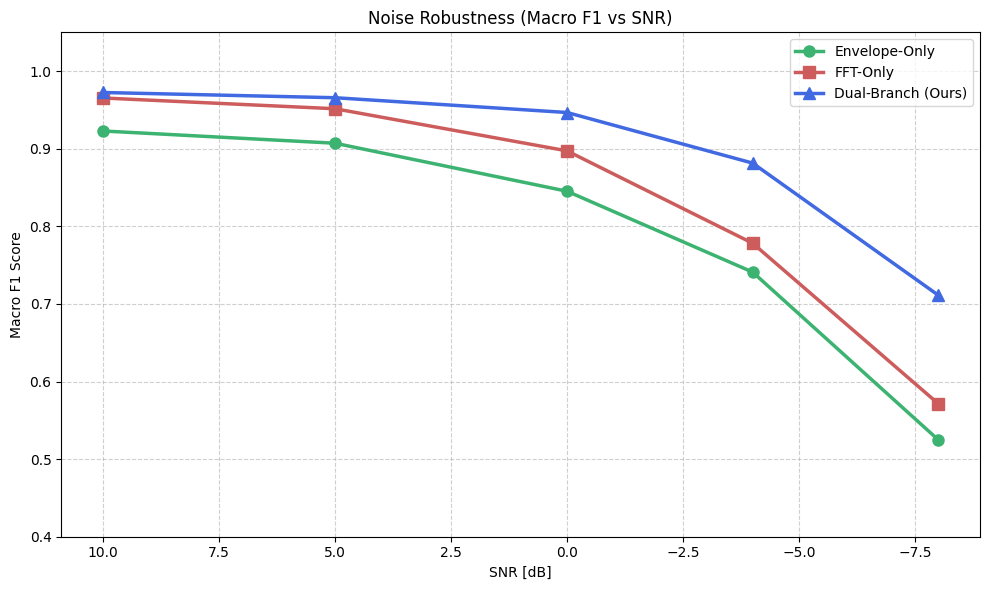

In [ ]:
def run_noise_robustness(model_constructors, config,
                         train_snr_values=None, test_snr_list=None, epochs=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    processor = UOSPreProcessor(config['root_dir'], config['bearing_name'])
    test_snr_list = test_snr_list or [10, 5, 0, -4, -8]
    results = {name: [] for name in model_constructors}

    # === Train data with random noise (if any), use the first 70% time part in the file ===
    train_data, _ = processor.load_data(
        config['all_speeds'],
        snr_values=train_snr_values,
        fs_folder=config['fs_folder'],
        max_segs=100,
        train_ratio=0.7
    )

    train_dl = DataLoader(
        MultiLabelDataset(train_data['env'], train_data['fft'], train_data['label']),
        batch_size=config['batch_size'],
        shuffle=True
    )

    for name, constructor in model_constructors.items():
        print(f"\n{'='*50}\nTraining (noise-robust): {name}\n{'='*50}")
        model = train_model(constructor(), train_dl, epochs, device)

        for snr in test_snr_list:
            print(f"\n-> Test SNR = {snr} dB")

            # === Test data: use the last 30% time part in the file, add noise according to snr ===
            _, test_data = processor.load_data(
                config['all_speeds'],
                snr=snr,
                fs_folder=config['fs_folder'],
                max_segs=20,
                train_ratio=0.7
            )

            test_dl = DataLoader(
                MultiLabelDataset(test_data['env'], test_data['fft'], test_data['label']),
                batch_size=config['batch_size'],
                shuffle=False
            )

            y_true, y_pred, _ = evaluate_model(model, test_dl, device)
            _, _, f1_macro, _ = precision_recall_fscore_support(
                y_true, y_pred, average='macro', zero_division=0
            )
            results[name].append(f1_macro)
            print(f" Macro F1 = {f1_macro:.4f}")

        del model
        torch.cuda.empty_cache()

    # Plot remains the same as your old code
    plt.figure(figsize=(10, 6))
    markers = ['o', 's', '^']
    colors = ['mediumseagreen', 'indianred', 'royalblue']
    for (name, scores), m, c in zip(results.items(), markers, colors):
        plt.plot(test_snr_list, scores, marker=m, lw=2.5, ms=8, label=name, color=c)
    plt.gca().invert_xaxis()
    plt.title('Noise Robustness (Macro F1 vs SNR)')
    plt.xlabel('SNR [dB]')
    plt.ylabel('Macro F1 Score')
    plt.ylim(0.4, 1.05)
    plt.grid(True, ls='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results


# Enable/disable noise robustness experiment
RUN_NOISE_EXPERIMENT = True

if RUN_NOISE_EXPERIMENT:
    model_ctors = {
        "Envelope-Only":      lambda: SingleBranchModel(mode="env"),
        "FFT-Only":           lambda: SingleBranchModel(mode="fft"),
        "Dual-Branch (Ours)": lambda: AttentionFusionModel(),
    }
    noise_results = run_noise_robustness(
        model_ctors,
        CONFIG,
        train_snr_values=[20, 15, 10, 5, 0, -4, -8],
        test_snr_list=[10, 5, 0, -4, -8],
        epochs=50,
    )

## Ablation Study

In [ ]:
# def run_ablation(config):
#     device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     processor = UOSPreProcessor(config['root_dir'], config['bearing_name'])
#     data      = processor.process_all_speeds(config['all_speeds'])
#     train_dl, test_dl = make_loaders(data, config['batch_size'])

#     models = {
#         'Envelope-Only':    SingleBranchModel(mode='env'),
#         'FFT-Only':         SingleBranchModel(mode='fft'),
#         'Dual-Branch (Ours)': AttentionFusionModel(),
#     }

#     print("\n" + "="*60)
#     print("  ABLATION STUDY")
#     print("="*60)
#     for name, model in models.items():
#         print(f"\n>>> Training: {name}...")
#         train_model(model, train_dl, config['epochs'], device)
#         y_true, y_pred, _ = evaluate_model(model, test_dl, device)
#         acc = accuracy_score(y_true, y_pred)
#         print(f"Completed {name}. Global Accuracy: {acc*100:.2f}%")

# run_ablation(CONFIG)

## Threshold Calibration

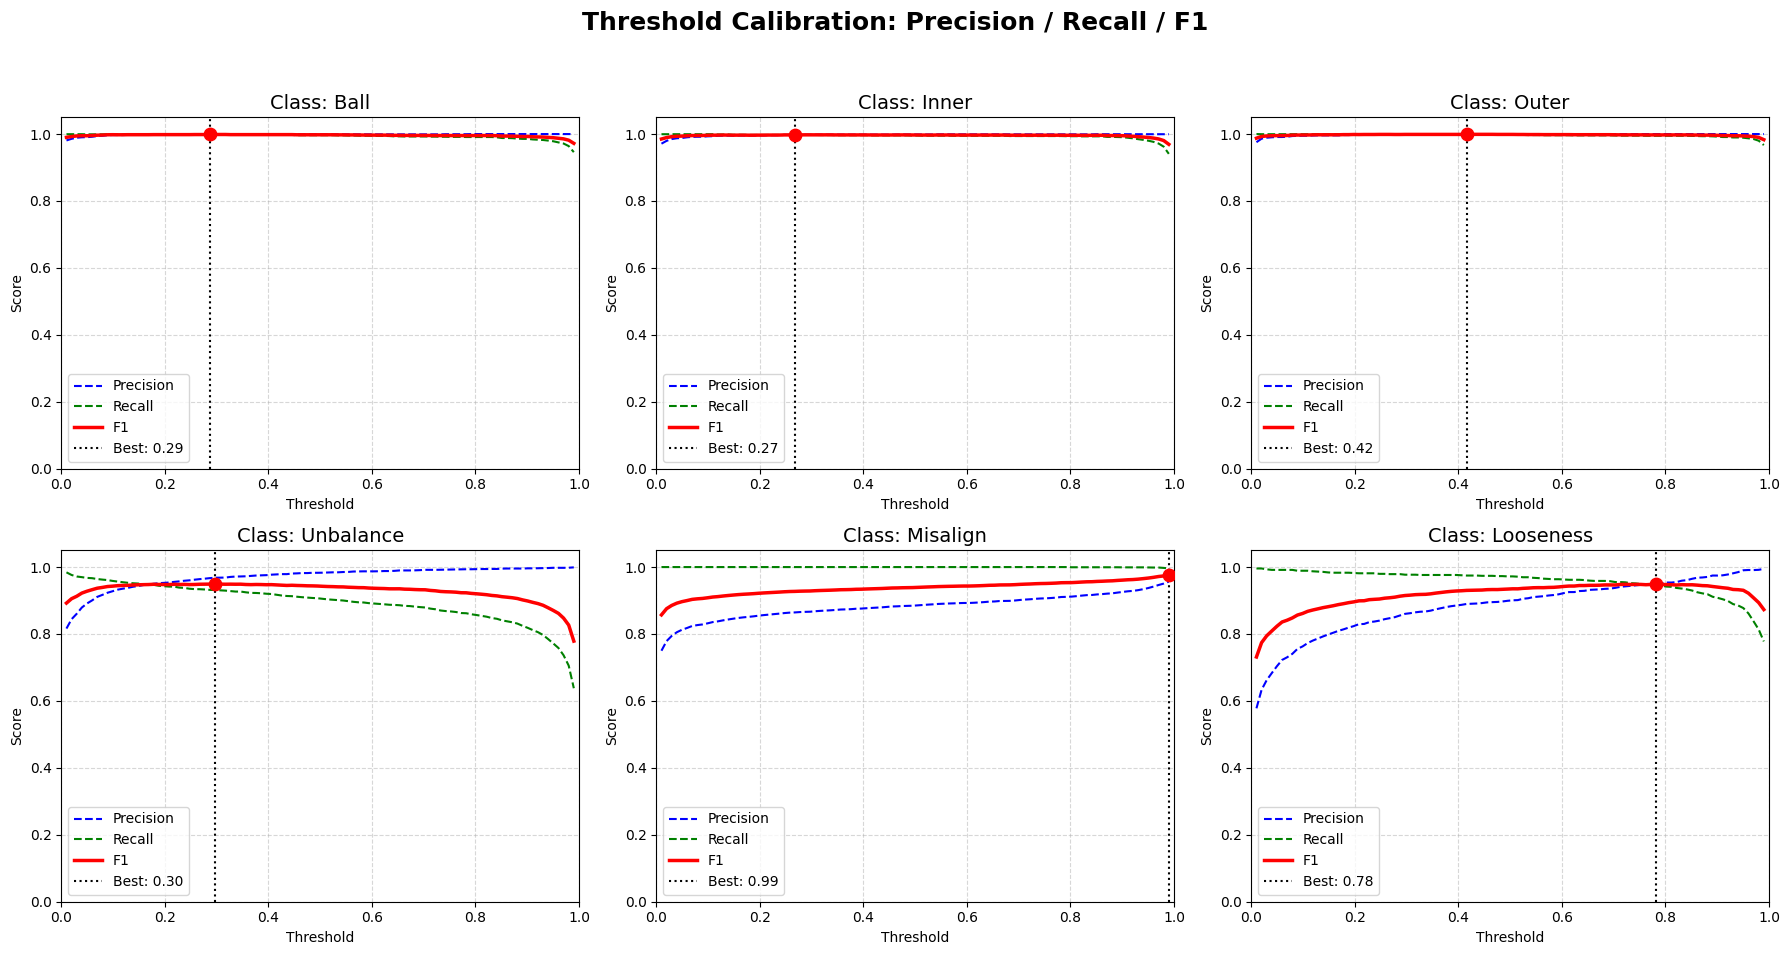


 NGƯỠNG PHÂN LOẠI TỐI ƯU (DỰA TRÊN MAX F1-SCORE) 
Lỗi: Ball         -> Threshold tối ưu: 0.29
Lỗi: Inner        -> Threshold tối ưu: 0.27
Lỗi: Outer        -> Threshold tối ưu: 0.42
Lỗi: Unbalance    -> Threshold tối ưu: 0.30
Lỗi: Misalign     -> Threshold tối ưu: 0.99
Lỗi: Looseness    -> Threshold tối ưu: 0.78


In [ ]:
def plot_metrics_vs_threshold(y_true, y_probs, target_names=TARGET_NAMES):
    thresholds = np.linspace(0.01, 0.99, 100)
    num_classes = y_true.shape[1]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    fig.suptitle('Threshold Calibration: Precision / Recall / F1', fontsize=18, fontweight='bold')

    best_thresholds = []

    for i in range(num_classes):
        yt = y_true[:, i]
        yp = y_probs[:, i]
        P, R, F = [], [], []
        for th in thresholds:
            pred = (yp >= th).astype(int)
            p, r, f, _ = precision_recall_fscore_support(
                yt, pred, average='binary', zero_division=0
            )
            P.append(p); R.append(r); F.append(f)

        best_idx = int(np.argmax(F))
        best_th  = thresholds[best_idx]
        best_thresholds.append(best_th)

        ax = axes[i]
        ax.plot(thresholds, P, '--', label='Precision', color='blue')
        ax.plot(thresholds, R, '--', label='Recall',    color='green')
        ax.plot(thresholds, F,  '-', label='F1',        color='red', linewidth=2.5)
        ax.axvline(best_th, color='black', linestyle=':', label=f'Best: {best_th:.2f}')
        ax.scatter(best_th, F[best_idx], color='red', s=80, zorder=5)

        ax.set_title(f"Class: {target_names[i]}", fontsize=14)
        ax.set_xlabel("Threshold")
        ax.set_ylabel("Score")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='lower left')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\n" + "="*50)
    print(" OPTIMAL CLASSIFICATION THRESHOLDS (BASED ON MAX F1-SCORE) ")
    print("="*50)
    for name, th in zip(target_names, best_thresholds):
        print(f"Fault: {name:<12} -> Optimal Threshold: {th:.2f}")
    print("="*50)


# Example: use the clean-trained Dual-Branch model to calibrate threshold
dual_model = trained_models["Dual-Branch (Ours)"]
y_true_all, _, y_prob_all = evaluate_model(dual_model, test_loader, device, threshold=0.5)
plot_metrics_vs_threshold(y_true_all, y_prob_all, TARGET_NAMES)